<a href="https://colab.research.google.com/github/crystalclcm/Dissertation-Crystal-Matticks/blob/main/02_job_ads_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.listdir('/content/drive/MyDrive')


Mounted at /content/drive


['Easilet Lease Control Sheet.xlsx',
 'Easilet Lease Control Sheet.gsheet',
 'Car Spaces  Byrne Moore.xls',
 'Car Spaces  Byrne Moore.gsheet',
 'BW Contact Listing.xlsx',
 'BW Contact Listing.gsheet',
 'RH Customer listing.xlsx',
 'Parking control listing.xlsx',
 'Parking control listing.gsheet',
 'RH Customer listing.gsheet',
 'GLS Customer Listing.xlsx',
 'GLS Customer Listing.gsheet',
 'BM Listing.xlsx',
 'BM Listing.gsheet',
 'GCV Supplier Listing.xlsx',
 'GCV Supplier Listing.gsheet',
 'lease of unit 5, bymac(part 1).pdf',
 '30A BW lease agreement (second half).pdf',
 '30A BW lease agreement (first half).pdf',
 'lease of unit 5, bymac(part 2).pdf',
 '6 ferndale road letter of engagement.pdf',
 '36 st. fintan villas letter of engagement.pdf',
 '36 st. fintan villas lease agreement (part 1).pdf',
 '36 st.fintan villas lease agreement (part 2).pdf',
 '68 st. fintan villas letter of engagement.pdf',
 'index.pdf',
 'Document31 (2).pdf',
 'Document31 (2).gdoc',
 'Colab Notebooks',
 'Unt

In [3]:
pre_ai = pd.read_csv('/content/drive/MyDrive/pre_ai_full.csv')
post_ai = pd.read_csv('/content/adzuna_post_ai_final.csv')



In [4]:
Job_Postings = pd.read_csv('/content/JobPostings.csv')


In [5]:
pre_ai.columns


Index(['job_title', 'job_description', 'country', 'date_posted', 'source',
       'role', 'source_clean', 'skills'],
      dtype='object')

In [6]:
post_ai.columns


Index(['job_title', 'job_description', 'country', 'date_posted', 'source',
       'role'],
      dtype='object')

# standardise and align datasets

In [172]:
import pandas as pd


pre_ai_clean = pre_ai.copy()

pre_ai_clean = pre_ai_clean.rename(columns={
    'job_title': 'job_title',
    'job_description': 'raw_text',
    'date_posted': 'date_posted',
    'source_clean': 'source',
    'skills': 'skills_text'
})

post_ai_clean = post_ai.copy()

post_ai_clean = post_ai_clean.rename(columns={
    'job_title': 'job_title',
    'description': 'raw_text',
    'created': 'date_posted',
    'company': 'company',
    'location': 'location',
    'redirect_url': 'redirect_url'
})

post_ai_extra_clean = Job_Postings.copy()

post_ai_extra_clean = post_ai_extra_clean.rename(columns={
    'title': 'job_title',
    'full_description': 'raw_text',
    'created': 'date_posted',
    'skills_list': 'skills_text',
    'home_url': 'home_url'
})

unified_columns = [
    'job_title', 'company', 'location', 'country', 'date_posted', 'role',
    'source', 'industry', 'contract_type', 'contract_time',
    'salary_min', 'salary_max', 'salary_avg',
    'raw_text', 'clean_text', 'skills_text', 'seniority',
    'redirect_url', 'home_url'
]

for df in [pre_ai_clean, post_ai_clean, post_ai_extra_clean]:
    for col in unified_columns:
        if col not in df.columns:
            df[col] = None

pre_ai_clean = pre_ai_clean[unified_columns]
post_ai_clean = post_ai_clean[unified_columns]
post_ai_extra_clean = post_ai_extra_clean[unified_columns]

print("Standardisation complete.")


Standardisation complete.


In [8]:
def basic_clean(text):
    if pd.isna(text):
        return None
    text = str(text)
    text = text.lower()
    text = text.replace("\n", " ")
    text = " ".join(text.split())
    return text

pre_ai_clean["clean_text"] = pre_ai_clean["raw_text"].apply(basic_clean)
post_ai_clean["clean_text"] = post_ai_clean["raw_text"].apply(basic_clean)
post_ai_extra_clean["clean_text"] = post_ai_extra_clean["raw_text"].apply(basic_clean)

print("Basic cleaning done.")


Basic cleaning done.


/tmp/ipykernel_23473/3995996791.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_ai_extra_clean["clean_text"] = post_ai_extra_clean["raw_text"].apply(basic_clean)


In [9]:
print("PRE-AI duplicates:", pre_ai_clean.columns.duplicated().any())
print("POST-AI duplicates:", post_ai_clean.columns.duplicated().any())
print("EXTRA POST-AI duplicates:", post_ai_extra_clean.columns.duplicated().any())


PRE-AI duplicates: True
POST-AI duplicates: False
EXTRA POST-AI duplicates: False


In [10]:
# Remove duplicate columns from PRE-AI
pre_ai_clean = pre_ai_clean.loc[:, ~pre_ai_clean.columns.duplicated()]
print("PRE-AI duplicate columns removed.")


PRE-AI duplicate columns removed.


In [11]:
# Find columns all datasets share
common_cols = list(
    set(pre_ai_clean.columns) &
    set(post_ai_clean.columns) &
    set(post_ai_extra_clean.columns)
)

print("Number of shared columns:", len(common_cols))
print("Shared columns:", common_cols)


Number of shared columns: 19
Shared columns: ['source', 'seniority', 'job_title', 'salary_min', 'contract_time', 'salary_avg', 'raw_text', 'salary_max', 'company', 'location', 'contract_type', 'industry', 'skills_text', 'date_posted', 'role', 'clean_text', 'redirect_url', 'country', 'home_url']


In [12]:
pre_ai_clean = pre_ai_clean[common_cols]
post_ai_clean = post_ai_clean[common_cols]
post_ai_extra_clean = post_ai_extra_clean[common_cols]

print("Columns aligned.")


Columns aligned.


In [13]:
pre_ai_clean["ai_period"] = "pre_ai"
post_ai_clean["ai_period"] = "post_ai"
post_ai_extra_clean["ai_period"] = "post_ai"


In [14]:
job_ads_clean = pd.concat(
    [pre_ai_clean, post_ai_clean, post_ai_extra_clean],
    ignore_index=True
)


/tmp/ipykernel_23473/1891809547.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  job_ads_clean = pd.concat(


In [15]:
job_ads_clean["date_posted"].max()


'2026-04-14T16:25:23Z'

In [16]:
ads = job_ads_clean.copy()


In [17]:
ads["year"] = ads["date_posted"].astype(str).str[:4]
ads["year"] = ads["year"].astype(int)


In [18]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

german_stopwords = {"der","die","das","des","den","dem","ein","eine","einer","einem","als","und","mit","auf","im","in","am","op","al","er","met"}

stopwords = ENGLISH_STOP_WORDS.union(german_stopwords)

job_ads_clean["clean_text"] = job_ads_clean["clean_text"].apply(
    lambda x: " ".join(
        w for w in (x or "").split()
        if w not in stopwords and len(w) > 2
    )
)



In [19]:
job_ads_clean["ai_period"].value_counts()


,count
ai_period,
pre_ai,13036
post_ai,2867


In [20]:
job_ads_clean[job_ads_clean["ai_period"] == "post_ai"].shape


(2867, 20)

In [21]:
post_ai["role"].value_counts(dropna=False)


,count
role,
business_analyst,149
data_analyst,147
software_engineer,147
accountant,139


In [22]:
job_ads_clean["clean_text"] = job_ads_clean["clean_text"].fillna("")


### Skill extraction and merging

In [171]:

skill_list = [

    #technical/data
    "python", "sql", "excel", "java", "sas",
    "aws", "gcp", "azure", "spark",
    "tableau", "power bi", "matlab", "r",

    #finance/business
    "finance", "valuation", "derivatives", "risk management",
    "tax", "vat", "accounting", "budgeting",

    #Pharma/validation/Engineering
    "validation", "qualification", "calibration",
    "change control", "qms", "gmp", "csv",
    "equipment validation", "process validation",
    "cleaning validation", "iq", "oq", "pq",
    "capa", "deviation management",
    "quality assurance", "quality control",
    "pharmaceutical", "biotech", "manufacturing",

    #Softer Skills
    "communication", "analytical", "leadership",
    "collaboration", "problem solving", "teamwork",
    "attention to detail", "documentation",
    "project management", "stakeholder management",

    #Compliance/Regulatory
    "compliance", "regulatory", "audit", "sop"
]



In [25]:
skill_synonyms = {
    "excel": ["ms excel", "microsoft excel", "spreadsheet"],
    "python": ["python3", "py"],
    "sql": ["mysql", "postgres", "sql server"],
    "gcp": ["google cloud", "google cloud platform"],
    "aws": ["amazon web services", "ec2", "s3"],
    "azure": ["microsoft azure"],
    "communication": ["communication skills", "communicator"],
    "leadership": ["lead", "manage", "management"],
    "problem solving": ["problem-solving", "problem solving"],
    "validation": ["process validation", "equipment validation", "cleaning validation"],
    "csv": ["computer system validation"],
    "qms": ["quality management system"],
    "gmp": ["good manufacturing practice"],
    "capa": ["corrective and preventive action"],
}


In [26]:
import re

def extract_skills(text, skills, synonyms):
    if pd.isna(text):
        return []

    text = text.lower()
    text = re.sub(r"[-/]", " ", text)

    found = set()

    # direct matches
    for skill in skills:
        skill_norm = skill.lower()
        if re.search(rf"\b{re.escape(skill_norm)}\b", text):
            found.add(skill)

    # synonym matches
    for skill, syns in synonyms.items():
        for syn in syns:
            syn_norm = syn.lower()
            if re.search(rf"\b{re.escape(syn_norm)}\b", text):
                found.add(skill)

    return list(found)


In [32]:
print(ads.columns.tolist())


['source', 'seniority', 'job_title', 'salary_min', 'contract_time', 'salary_avg', 'raw_text', 'salary_max', 'company', 'location', 'contract_type', 'industry', 'skills_text', 'date_posted', 'role', 'clean_text', 'redirect_url', 'country', 'home_url', 'ai_period', 'year']


In [34]:
def extract_skills(text, skills):
    if pd.isna(text):
        return []

    found = []
    for skill in skills:
        if skill in text:
            found.append(skill)
    return found


In [35]:
def extract_skills(text, skills):
    if pd.isna(text):
        return []
    found = []
    for skill in skills:
        if skill in text:
            found.append(skill)
    return found


In [36]:
pre_ai_clean["extracted_skills"] = pre_ai_clean["clean_text"].apply(
    lambda x: extract_skills(x, skill_list)
)

post_ai_clean["extracted_skills"] = post_ai_clean["clean_text"].apply(
    lambda x: extract_skills(x, skill_list)
)

post_ai_extra_clean["extracted_skills"] = post_ai_extra_clean["clean_text"].apply(
    lambda x: extract_skills(x, skill_list)
)


In [37]:
job_ads_clean["extracted_skills"] = job_ads_clean["clean_text"].apply(
    lambda x: extract_skills(x, skill_list)
)


In [38]:
from collections import Counter

all_skills = job_ads_clean["extracted_skills"].sum()
skill_counts = Counter(all_skills)

skill_counts


Counter({'excel': 8493,
         'r': 15321,
         'vat': 7739,
         'iq': 3509,
         'pharmaceutical': 1838,
         'biotech': 681,
         'communication': 7630,
         'analytical': 2943,
         'manufacturing': 2323,
         'risk management': 563,
         'validation': 1820,
         'gmp': 862,
         'problem solving': 2132,
         'documentation': 2797,
         'project management': 1613,
         'qualification': 5271,
         'capa': 3447,
         'leadership': 2485,
         'collaboration': 2153,
         'finance': 2062,
         'quality assurance': 725,
         'compliance': 2656,
         'regulatory': 1755,
         'audit': 1774,
         'calibration': 122,
         'change control': 412,
         'qms': 143,
         'csv': 200,
         'equipment validation': 82,
         'oq': 220,
         'pq': 393,
         'sop': 868,
         'python': 3034,
         'java': 2476,
         'sas': 614,
         'sql': 3230,
         'gcp': 617,
   

In [39]:
skill_counts_df = pd.DataFrame.from_dict(skill_counts, orient='index', columns=['count'])
skill_counts_df.sort_values("count", ascending=False)


,count
r,15321
excel,8493
vat,7739
communication,7630
qualification,5271
iq,3509
capa,3447
sql,3230
python,3034
analytical,2943


In [41]:
job_ads_clean = pd.concat(
    [pre_ai_clean, post_ai_clean, post_ai_extra_clean],
    ignore_index=True
)


/tmp/ipykernel_23473/1891809547.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  job_ads_clean = pd.concat(


In [42]:
df = job_ads_clean.copy()


In [43]:
job_ads_clean.columns


Index(['source', 'seniority', 'job_title', 'salary_min', 'contract_time',
       'salary_avg', 'raw_text', 'salary_max', 'company', 'location',
       'contract_type', 'industry', 'skills_text', 'date_posted', 'role',
       'clean_text', 'redirect_url', 'country', 'home_url', 'ai_period',
       'extracted_skills'],
      dtype='object')

In [44]:
job_ads_clean["extracted_skills"].head()


,extracted_skills
0,"[excel, r, vat, iq, pharmaceutical, biotech, c..."
1,"[excel, r, vat, pharmaceutical, manufacturing]"
2,"[excel, r, risk management, validation, gmp, m..."
3,"[excel, r, vat, pharmaceutical, manufacturing]"
4,"[excel, r, vat, qualification, capa, pharmaceu..."


# Build the tfidf model

In [53]:
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer


In [54]:
noise_terms = [
    r"income statement[s]?",
    r"balance sheet[s]?",
    r"year[- ]?end",
    r"month[- ]?end",
    r"financial reporting",
    r"financial statement[s]?",
    r"accrual[s]?",
    r"journal entries?",
    r"gaap",
    r"ifrs",
    r"cost control",
    r"\baca\b",
    r"\bacca\b",
    r"\baudit(ing)?\b"
]


In [55]:
def clean_text(text):
    if text is None or pd.isna(text):
        return ""

    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    for term in noise_terms:
        text = text.replace(term, " ")

    return text


In [56]:
job_ads_clean["clean_text_no_noise"] = job_ads_clean["clean_text"].apply(clean_text)


In [168]:
vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=5,       # ignore noise
    max_df=0.8,     # ignore overly common terms
    stop_words="english"
)

tfidf_matrix = vectorizer.fit_transform(job_ads_clean["clean_text_no_noise"])
feature_names = vectorizer.get_feature_names_out()


In [58]:
import numpy as np

def top_terms_from_sparse(row, feature_names, top_n=10):
    # row is a sparse matrix row
    data = row.data
    indices = row.indices

    if len(data) == 0:
        return []

    top_idx = data.argsort()[-top_n:]
    return [feature_names[indices[i]] for i in top_idx]

job_ads_clean["tfidf_top_terms"] = [
    top_terms_from_sparse(tfidf_matrix[i], feature_names)
    for i in range(tfidf_matrix.shape[0])
]


In [59]:
from collections import Counter
Counter([t for sub in job_ads_clean["tfidf_top_terms"] for t in sub]).most_common(50)


[('data', 2392),
 ('sales', 869),
 ('business', 738),
 ('software', 573),
 ('ai', 444),
 ('design', 443),
 ('project', 436),
 ('equipment', 414),
 ('manufacturing', 410),
 ('test', 371),
 ('quality', 368),
 ('engineering', 365),
 ('security', 363),
 ('accounting', 350),
 ('cloud', 347),
 ('automation', 345),
 ('customer', 342),
 ('validation', 336),
 ('analytics', 320),
 ('financial', 307),
 ('process', 300),
 ('product', 291),
 ('development', 262),
 ('medical', 257),
 ('clinical', 253),
 ('accounts', 252),
 ('net', 244),
 ('accountant', 240),
 ('customers', 232),
 ('technical', 225),
 ('ll', 216),
 ('finance', 215),
 ('testing', 214),
 ('developer', 211),
 ('reperio', 206),
 ('amazon', 201),
 ('maintenance', 198),
 ('systems', 196),
 ('sigmar', 193),
 ('business development', 191),
 ('network', 191),
 ('preparation', 191),
 ('service', 189),
 ('management', 188),
 ('qa', 187),
 ('electrical', 187),
 ('azure', 186),
 ('learning', 186),
 ('hr', 184),
 ('support', 181)]

# build role classifier

In [60]:
ads["role_text"] = (
    ads["job_title"].fillna("").astype(str).str.lower() + " " +
    ads["clean_text"].fillna("").astype(str).str.lower()
)


In [167]:
def assign_role(text):
    text = str(text).lower()

    if "data engineer" in text or "analytics engineer" in text:
        return "data_engineer"
    if "machine learning engineer" in text or "ml engineer" in text:
        return "ml_engineer"
    if "software engineer" in text or "developer" in text or "full stack" in text or "backend" in text or "frontend" in text or "cloud engineer" in text or "platform engineer" in text:
        return "software_engineer"
    if "data analyst" in text:
        return "data_analyst"
    if "business analyst" in text or "insight analyst" in text or "bi analyst" in text:
        return "business_analyst"
    if "data scientist" in text or "machine learning" in text:
        return "data_scientist"
    if "financial analyst" in text or "finance analyst" in text or "fp&a" in text:
        return "financial_analyst"
    if "risk analyst" in text or "risk and compliance" in text:
        return "risk_analyst"
    if "accountant" in text or "accounting" in text or "audit" in text or "tax accountant" in text:
        return "accountant"

    return "unknown"


In [62]:
ads["role"] = ads["role_text"].apply(assign_role)


In [63]:
ads["role"].value_counts()


,count
role,
unknown,6677
software_engineer,3866
accountant,2231
data_engineer,1090
data_analyst,673
data_scientist,622
business_analyst,433
ml_engineer,178
risk_analyst,92


# Time series matrix

In [165]:
ads = ads[ads["year"].between(2018, 2025)]


In [166]:
#normalize text
ads["clean_text"] = (
    ads["clean_text"]
    .fillna("")
    .str.lower()
    .str.replace(r"[^a-z\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
)

#deifning the broader skill patterns
skill_patterns = {
     "python": r"\bpython\b",
    "sql": r"\bsql\b",
    "excel": r"\bexcel\b",
    "tableau": r"\btableau\b",
    "powerbi": r"\bpower\s*bi\b",
    "r": r"\br programming\b|\br language\b|\br\b",
    "machine_learning": r"\bmachine learning\b|\bml\b",
    "cloud": r"\baws\b|\bazure\b|\bgcp\b|\bcloud\b",
    "statistics": r"\bstatistics\b|\bstatistical\b",
    "communication": r"\bcommunication\b|\bcommunicate\b",
    "teamwork": r"\bteamwork\b|\bteam player\b",
    "problem_solving": r"\bproblem solving\b|\bsolve problems\b",
    "finance": r"\bfinance\b",
    "accounting": r"\baccounting\b",
    "budgeting": r"\bbudgeting\b|\bbudget\b",
    "forecasting": r"\bforecasting\b|\bforecast\b"
}

#Create indicator columns
for skill, pattern in skill_patterns.items():
    ads[skill] = ads["clean_text"].str.contains(pattern, regex=True).astype(int)

#group by year and role
time_series_year = (
    ads.groupby(["year", "role"])[list(skill_patterns.keys())]
       .sum()
       .reset_index()
       .sort_values(["year", "role"])
)

time_series_year

,year,role,python,sql,excel,tableau,powerbi,r,machine_learning,cloud,statistics,communication,teamwork,problem_solving,finance,accounting,budgeting,forecasting
0,2018,accountant,0,0,0,0,0,13,0,24,9,61,10,22,0,0,5,0
1,2018,business_analyst,0,1,8,0,1,0,0,2,0,9,4,6,4,0,4,7
2,2018,data_analyst,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0
3,2018,data_engineer,6,0,0,0,0,0,6,6,0,0,0,0,0,0,0,0
4,2018,data_scientist,3,17,0,0,0,0,3,40,6,0,31,31,17,0,16,16
5,2018,software_engineer,22,0,0,0,0,15,0,8,11,1,0,0,0,0,0,0
6,2018,unknown,4,2,61,0,1,78,0,66,27,334,47,96,36,0,56,22
7,2020,accountant,7,28,314,16,13,79,0,33,89,485,185,219,369,431,164,111
8,2020,business_analyst,3,12,19,11,2,7,3,24,6,58,17,24,31,9,7,6
9,2020,data_analyst,74,97,34,41,66,69,52,54,60,115,17,34,36,8,5,8


# pre vs post ai

In [75]:
import matplotlib.pyplot as plt


In [76]:
ads["technical"] = ads[["python","sql","excel"]].sum(axis=1)
ads["business"] = ads[["finance","accounting"]].sum(axis=1)
ads["soft"] = ads[["communication"]].sum(axis=1)


In [83]:
ads["technical_per_100"] = ads["technical"] * 100
ads["business_per_100"] = ads["business"] * 100
ads["soft_per_100"] = ads["soft"] * 100


In [84]:
pre_post_cat = (
    ads.groupby(["ai_period", "role"])[["technical","business","soft"]]
       .mean()
       .reset_index()
)


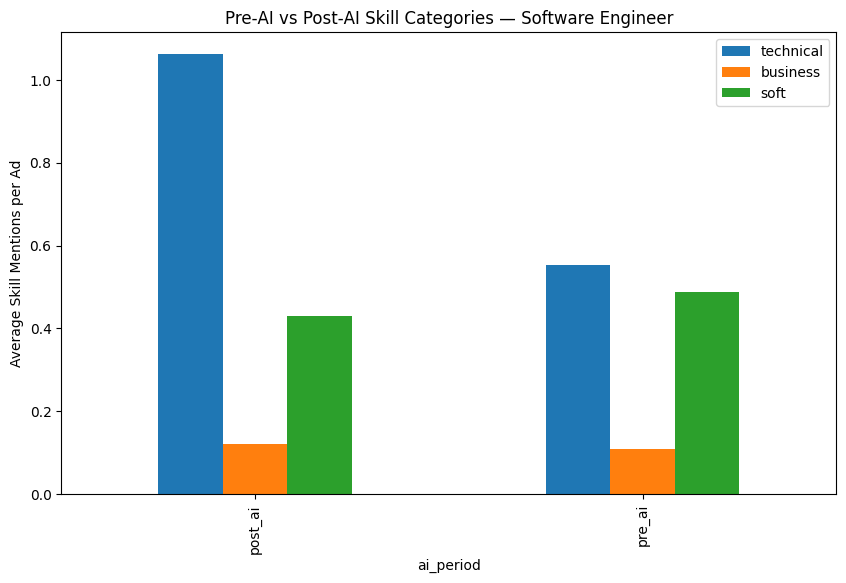

In [85]:
df = pre_post_cat[pre_post_cat["role"] == "software_engineer"]

df.plot(
    x="ai_period",
    y=["technical","business","soft"],
    kind="bar",
    figsize=(10,6),
    title="Pre‑AI vs Post‑AI Skill Categories — Software Engineer"
)
plt.ylabel("Average Skill Mentions per Ad")
plt.show()


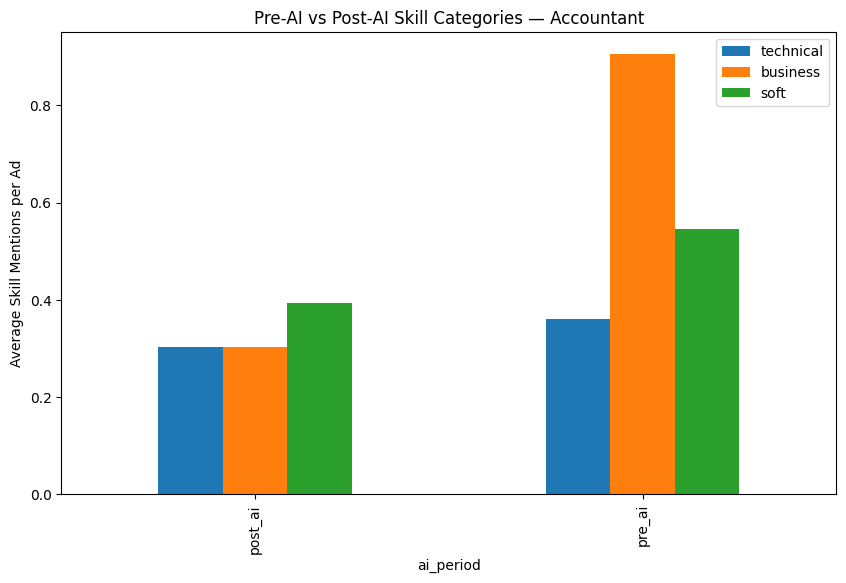

In [86]:
df = pre_post_cat[pre_post_cat["role"] == "accountant"]

df.plot(
    x="ai_period",
    y=["technical","business","soft"],
    kind="bar",
    figsize=(10,6),
    title="Pre‑AI vs Post‑AI Skill Categories — Accountant"
)
plt.ylabel("Average Skill Mentions per Ad")
plt.show()

In [159]:
# Count total job ads in each period
total_pre = job_ads_clean[job_ads_clean["ai_period"] == "pre_ai"].shape[0]
total_post = job_ads_clean[job_ads_clean["ai_period"] == "post_ai"].shape[0]

# Count skill frequencies
pre_counts = job_skills[job_skills["ai_period"] == "pre_ai"]["skill"].value_counts()
post_counts = job_skills[job_skills["ai_period"] == "post_ai"]["skill"].value_counts()

# Combine using OUTER JOIN (union of all skills)
skill_comparison = pd.concat([pre_counts, post_counts], axis=1, join="outer")
skill_comparison.columns = ["pre_ai", "post_ai"]
skill_comparison = skill_comparison.fillna(0)

# Normalise per 1000 job ads
skill_comparison["pre_ai_per_1000"] = (skill_comparison["pre_ai"] / total_pre) * 1000
skill_comparison["post_ai_per_1000"] = (skill_comparison["post_ai"] / total_post) * 1000

# Add total column
skill_comparison["total"] = skill_comparison["pre_ai"] + skill_comparison["post_ai"]

# Select top 20 skills by total frequency
top_skills = skill_comparison.sort_values("total", ascending=False).head(20)

top_skills


,pre_ai,post_ai,pre_ai_per_1000,post_ai_per_1000,total
skill,,,,,
r,13036.0,2285.0,1000.000000,797.000349,15321.0
excel,7305.0,1188.0,560.371280,414.370422,8493.0
vat,6375.0,1364.0,489.030377,475.758633,7739.0
communication,6577.0,1053.0,504.525928,367.282874,7630.0
qualification,4722.0,549.0,362.227677,191.489362,5271.0
iq,2726.0,810.0,209.113225,282.525288,3536.0
capa,2773.0,674.0,212.718625,235.088943,3447.0
sql,2060.0,1170.0,158.023934,408.092082,3230.0
python,1708.0,1326.0,131.021786,462.504360,3034.0


<Axes: title={'center': 'Top Skills per 1000 Job Ads: Pre-AI vs Post-AI'}, xlabel='skill', ylabel='Mentions per 1000 job ads'>

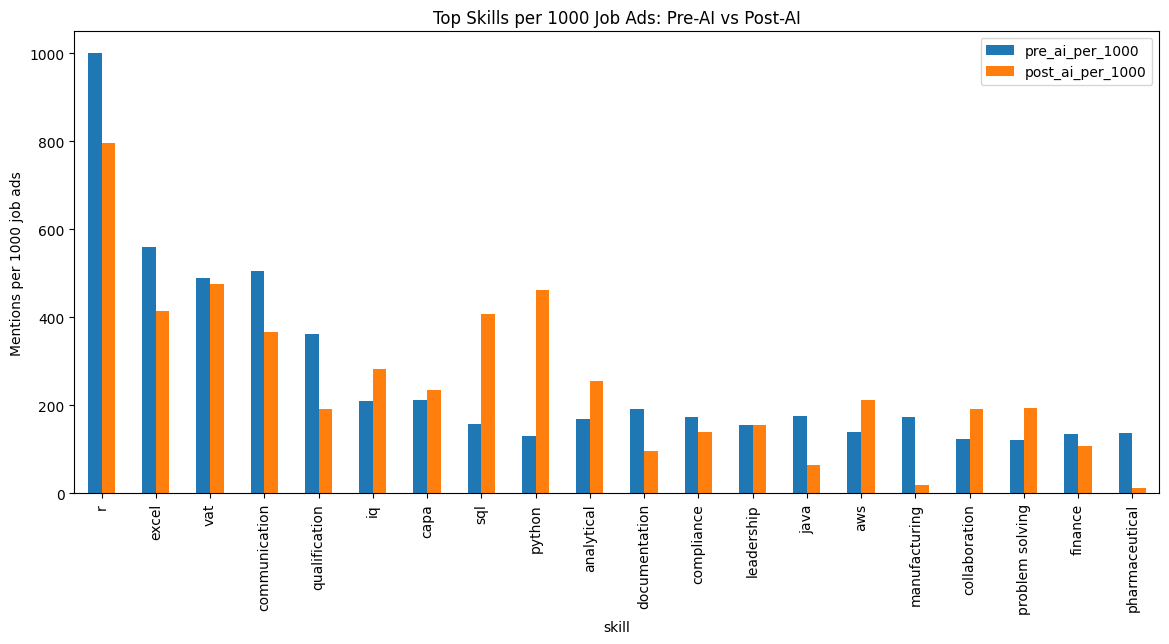

In [160]:
top_skills[["pre_ai_per_1000", "post_ai_per_1000"]].plot(
    kind="bar",
    figsize=(14,6),
    title="Top Skills per 1000 Job Ads: Pre-AI vs Post-AI",
    ylabel="Mentions per 1000 job ads"
)


# Forecasting

In [88]:
merged_groups = ads.groupby(["year", "role"])[
    ["technical_per_100", "business_per_100", "soft_per_100"]
].mean().reset_index()


In [89]:
df = merged_groups[merged_groups["role"] == "software_engineer"][["year", "technical_per_100"]].copy()
df = df.rename(columns={"year": "ds", "technical_per_100": "y"})


In [90]:
df["ds"] = pd.to_datetime(df["ds"], format="%Y")


In [91]:
from prophet import Prophet

model = Prophet()
model.fit(df)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 4.


In [92]:
future = model.make_future_dataframe(periods=3, freq="Y")
forecast = model.predict(future)


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


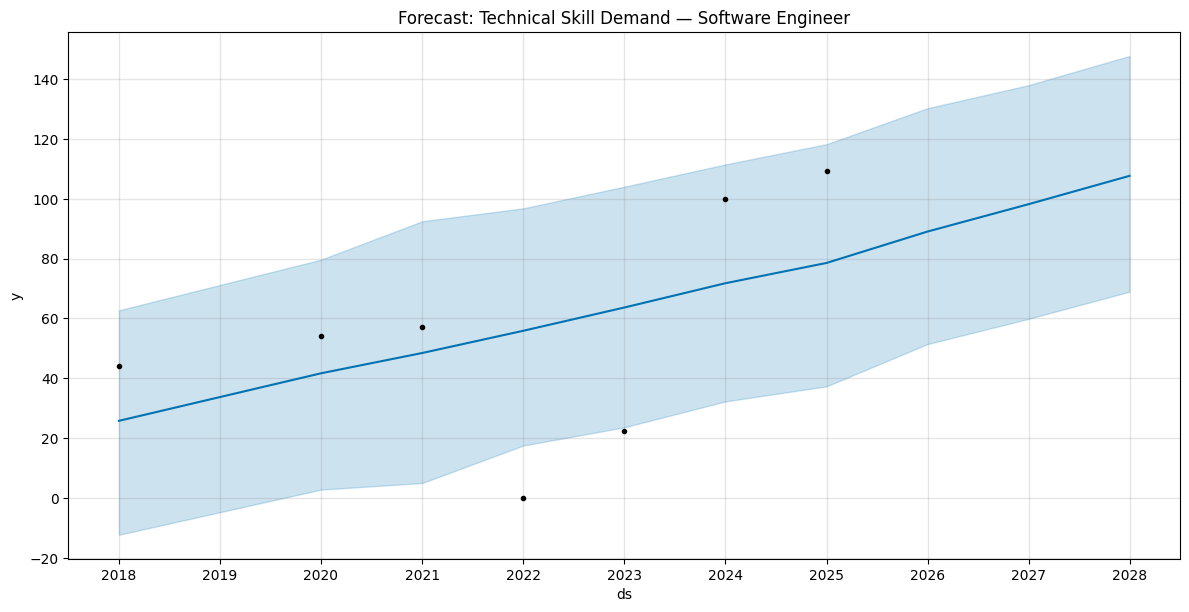

In [93]:
model.plot(forecast, figsize=(12,6))
plt.title("Forecast: Technical Skill Demand — Software Engineer")
plt.show()


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


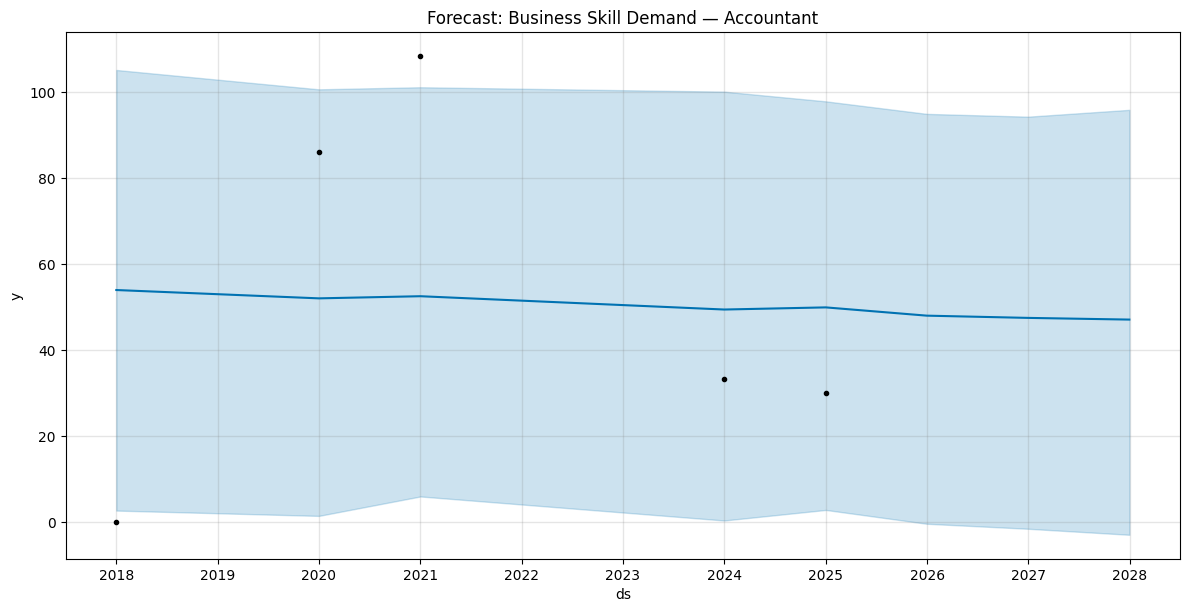

In [94]:
df = merged_groups[merged_groups["role"] == "accountant"][["year", "business_per_100"]].copy()
df = df.rename(columns={"year": "ds", "business_per_100": "y"})
df["ds"] = pd.to_datetime(df["ds"], format="%Y")

model = Prophet()
model.fit(df)

future = model.make_future_dataframe(periods=3, freq="Y")
forecast = model.predict(future)

model.plot(forecast, figsize=(12,6))
plt.title("Forecast: Business Skill Demand — Accountant")
plt.show()


In [95]:
from prophet import Prophet
import matplotlib.pyplot as plt

def forecast_role(df, role, skill_col, title_suffix):
    data = df[df["role"] == role][["year", skill_col]].copy()
    data = data.rename(columns={"year": "ds", skill_col: "y"})
    data["ds"] = pd.to_datetime(data["ds"], format="%Y")

    model = Prophet()
    model.fit(data)

    future = model.make_future_dataframe(periods=3, freq="Y")
    forecast = model.predict(future)

    model.plot(forecast, figsize=(12,6))
    plt.title(f"Forecast: {title_suffix} — {role}")
    plt.show()


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


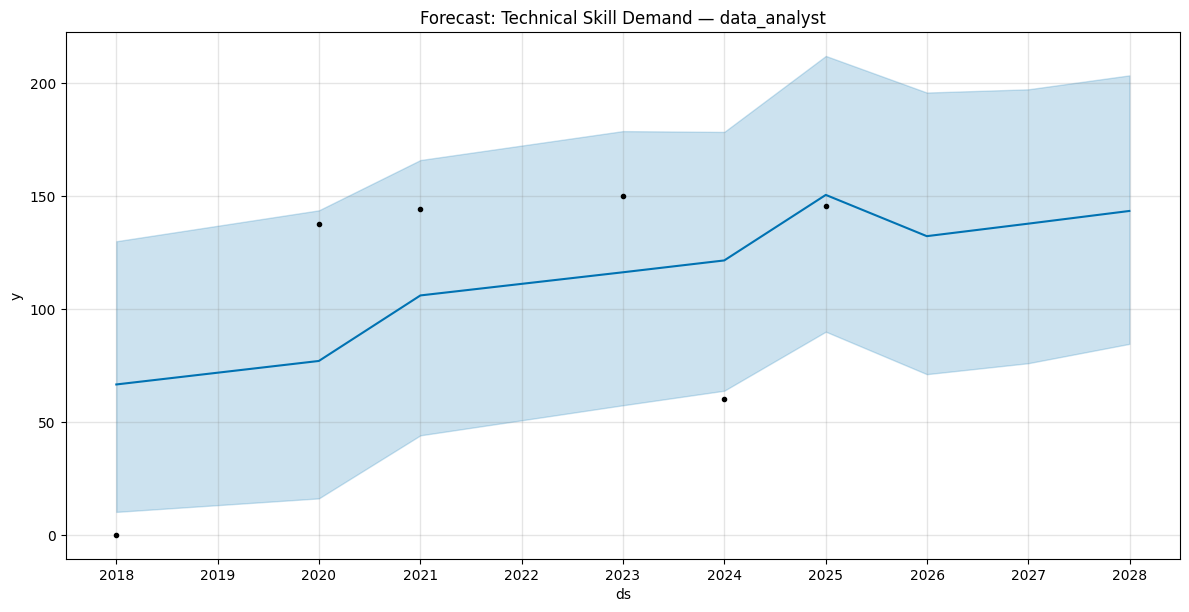

In [96]:
forecast_role(merged_groups, "data_analyst", "technical_per_100", "Technical Skill Demand")


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


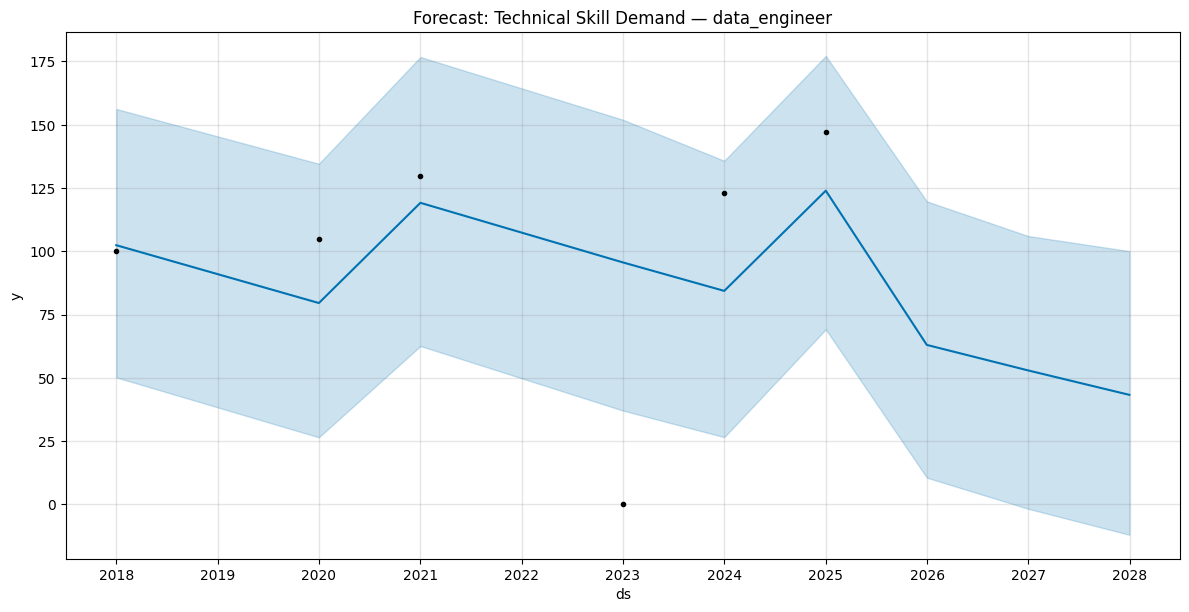

In [97]:
forecast_role(merged_groups, "data_engineer", "technical_per_100", "Technical Skill Demand")


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


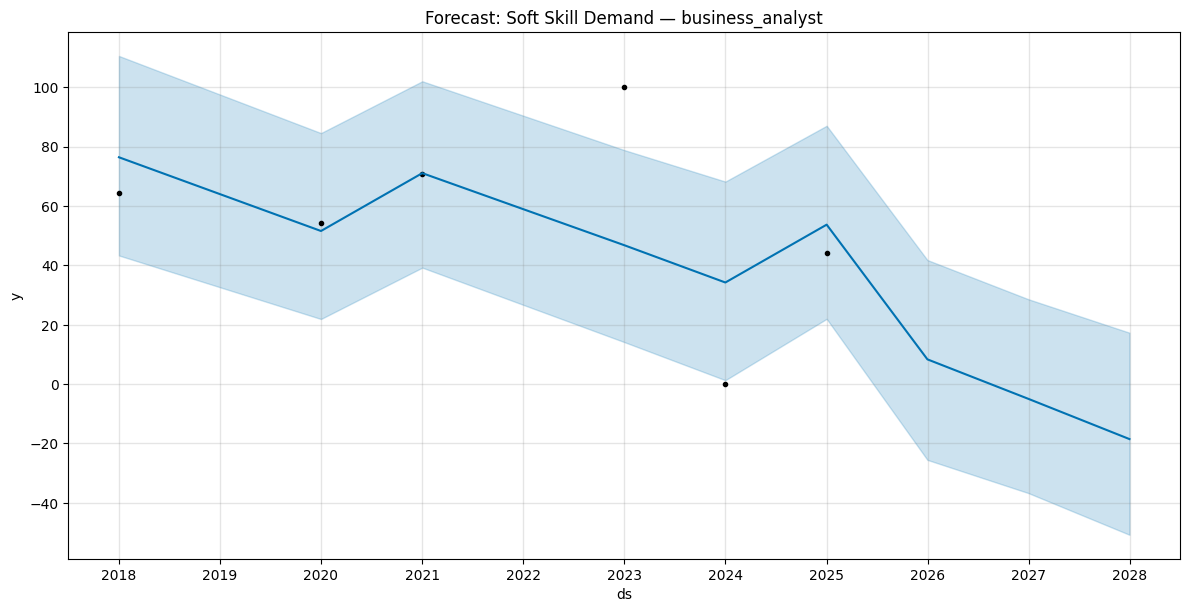

In [98]:
forecast_role(merged_groups, "business_analyst", "soft_per_100", "Soft Skill Demand")


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


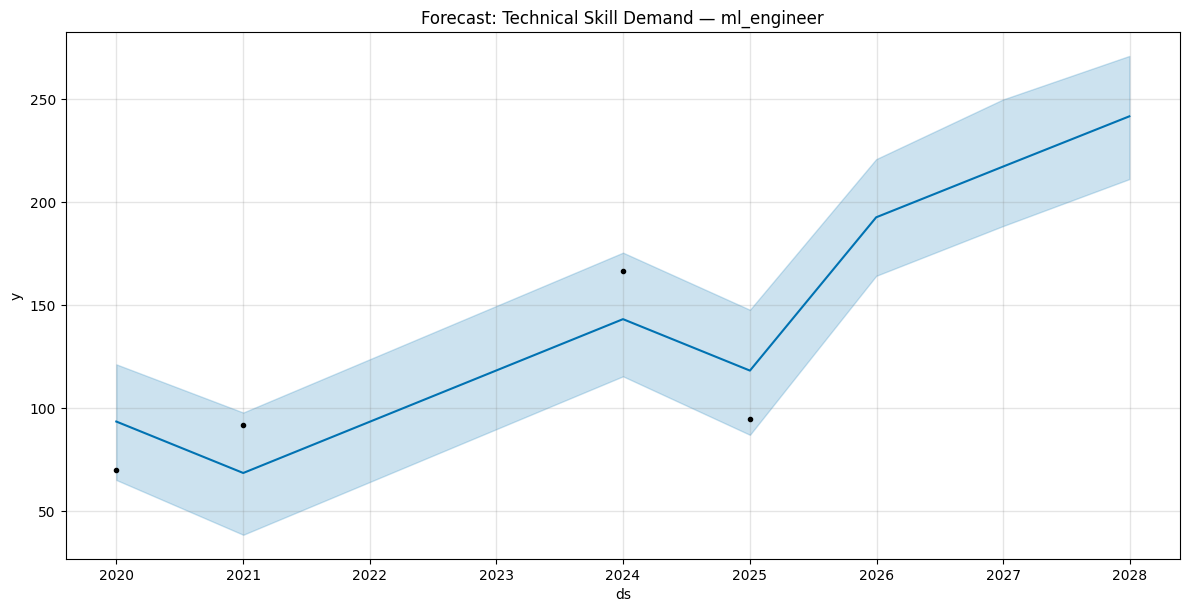

In [99]:
forecast_role(merged_groups, "ml_engineer", "technical_per_100", "Technical Skill Demand")


# integrating monthly analysis

In [100]:
import pandas as pd
import numpy as np

def yearly_to_monthly(df, value_col):
    monthly_rows = []

    for _, row in df.iterrows():
        year = int(row["year"])
        value = row[value_col]

        for month in range(1, 13):
            monthly_rows.append({
                "ds": pd.Timestamp(year=year, month=month, day=1),
                "y": value
            })

    return pd.DataFrame(monthly_rows)


In [101]:
def add_small_noise(df, noise_level=0.5):
    df["y"] = df["y"] + np.random.normal(0, noise_level, size=len(df))
    return df


In [102]:
yearly = merged_groups[merged_groups["role"] == "data_analyst"][["year", "technical_per_100"]]

monthly = yearly_to_monthly(yearly, "technical_per_100")
monthly = add_small_noise(monthly)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


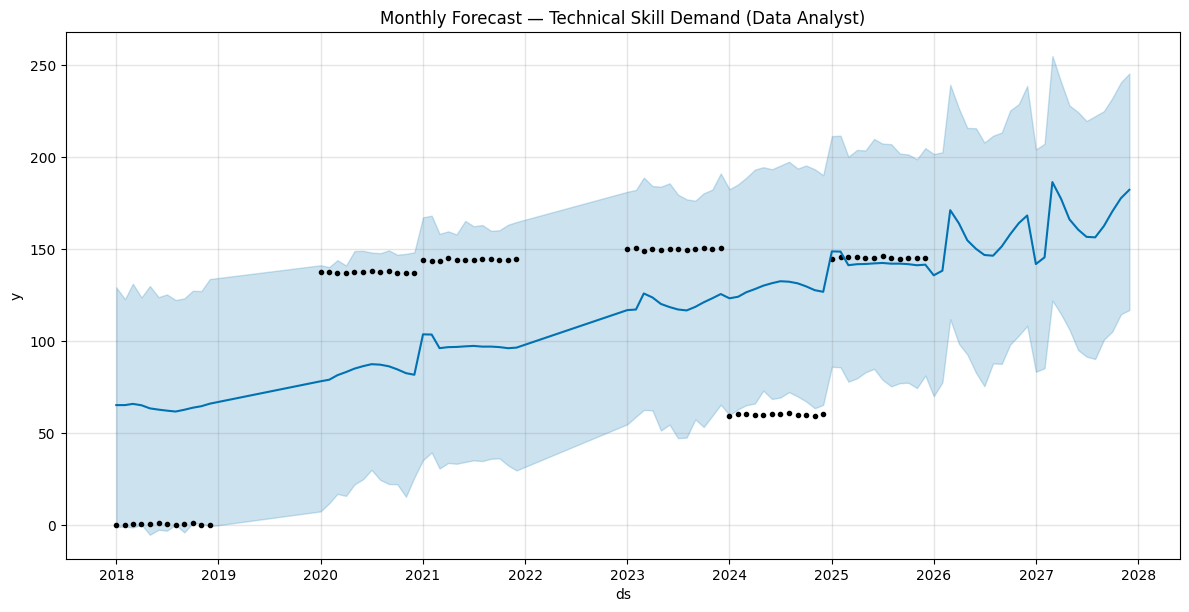

In [103]:
from prophet import Prophet

model = Prophet()
model.fit(monthly)

future = model.make_future_dataframe(periods=24, freq="M")  # forecast 2 years monthly
forecast = model.predict(future)

model.plot(forecast, figsize=(12,6))
plt.title("Monthly Forecast — Technical Skill Demand (Data Analyst)")
plt.show()


In [104]:
from prophet import Prophet
import matplotlib.pyplot as plt

def monthly_forecast(merged_groups, role, skill_col, title_suffix):
    yearly = merged_groups[merged_groups["role"] == role][["year", skill_col]]
    monthly = yearly_to_monthly(yearly, skill_col)
    monthly = add_small_noise(monthly)

    model = Prophet()
    model.fit(monthly)

    future = model.make_future_dataframe(periods=24, freq="M")
    forecast = model.predict(future)

    model.plot(forecast, figsize=(12,6))
    plt.title(f"Monthly Forecast — {title_suffix} ({role})")
    plt.show()


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


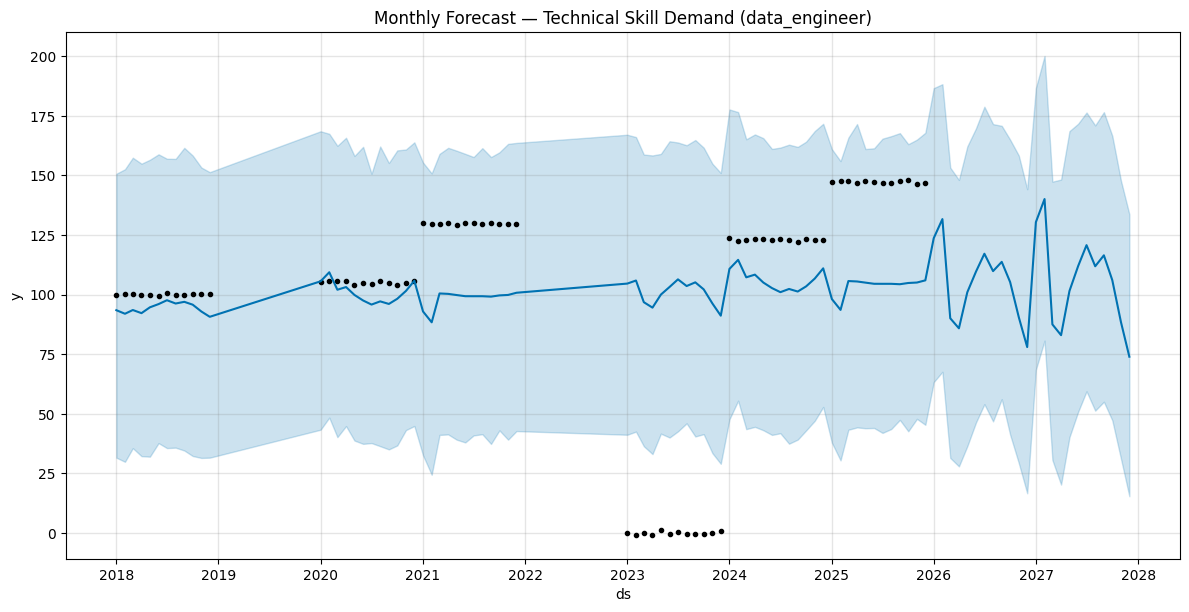

In [105]:
monthly_forecast(merged_groups, "data_engineer", "technical_per_100", "Technical Skill Demand")


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


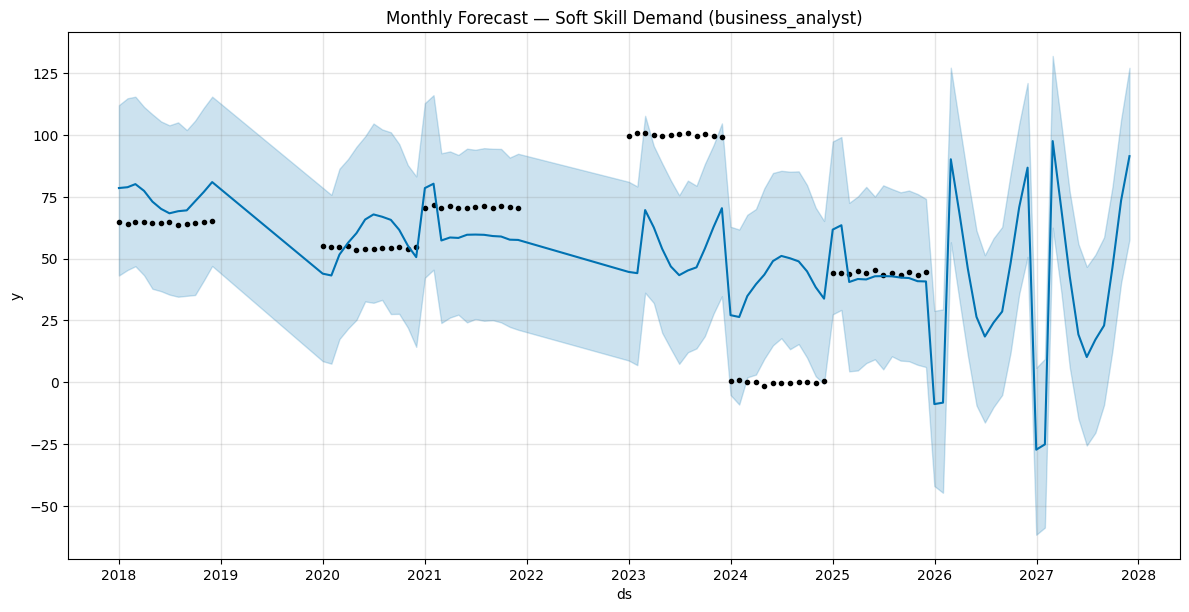

In [106]:
monthly_forecast(merged_groups, "business_analyst", "soft_per_100", "Soft Skill Demand")


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


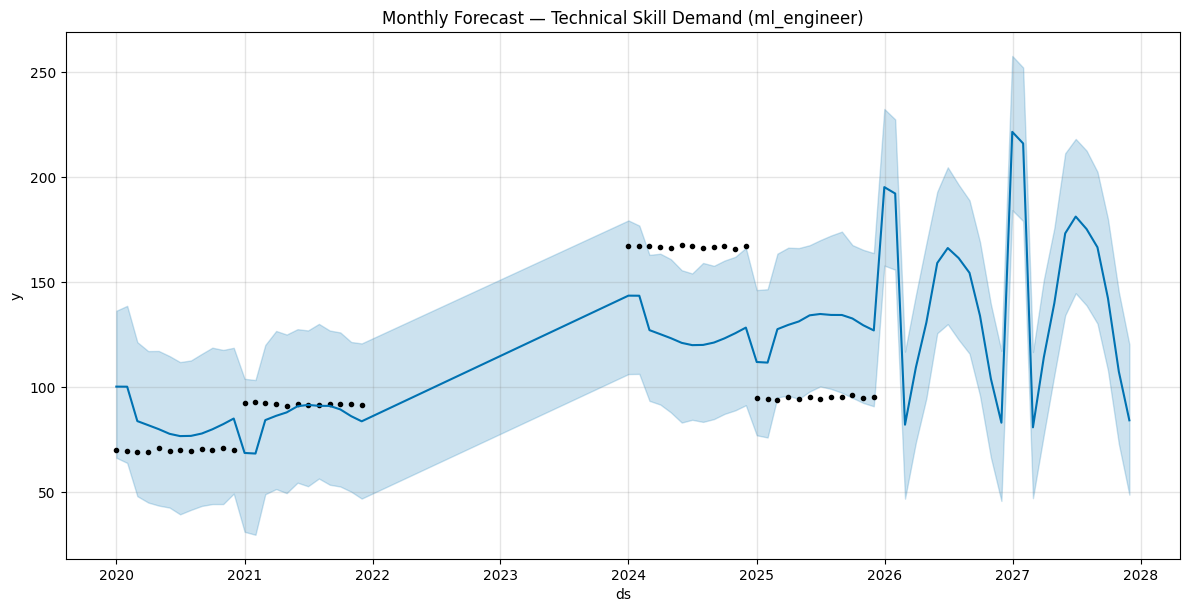

In [107]:
monthly_forecast(merged_groups, "ml_engineer", "technical_per_100", "Technical Skill Demand")


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


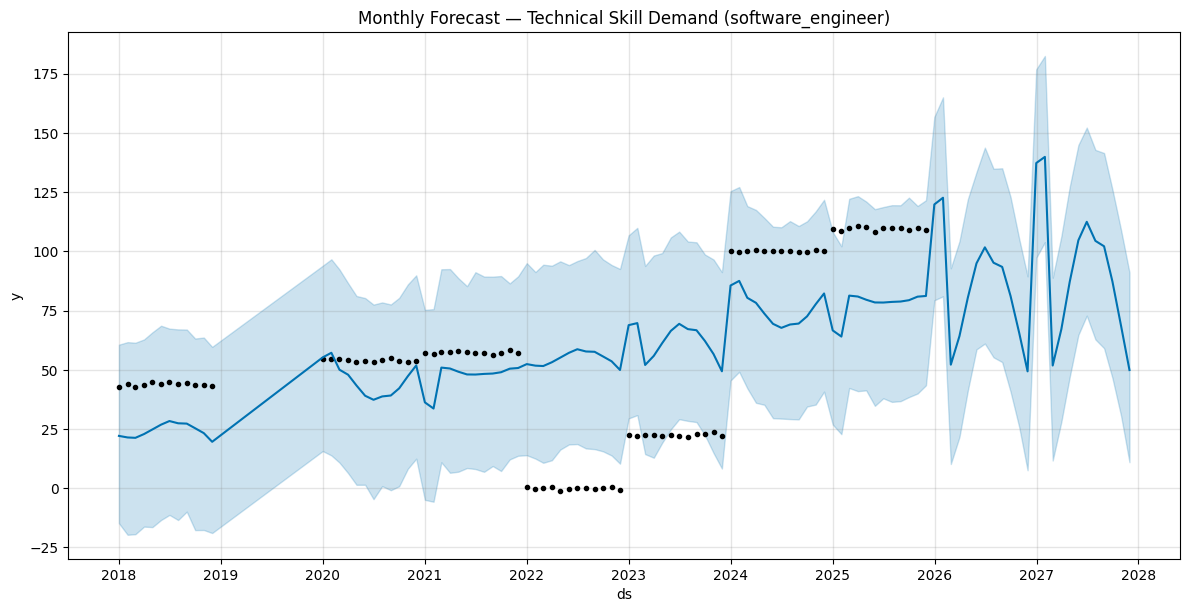

In [108]:
monthly_forecast(merged_groups, "software_engineer", "technical_per_100", "Technical Skill Demand")


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


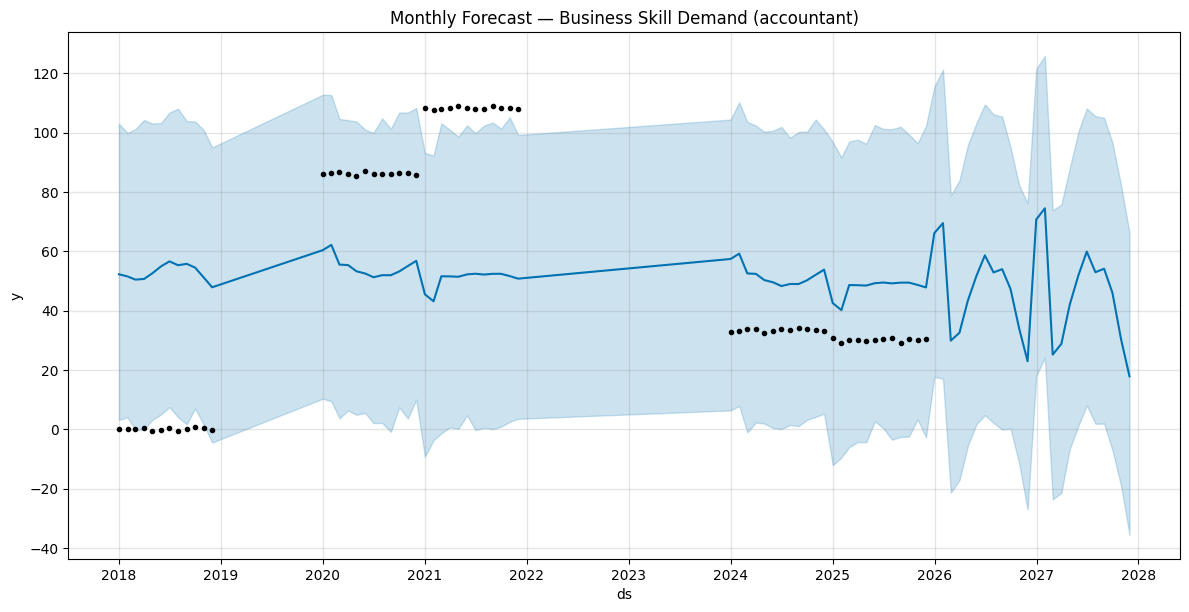

In [109]:
monthly_forecast(merged_groups, "accountant", "business_per_100", "Business Skill Demand")


# Top Skills 2028

In [110]:
def get_monthly_forecast_series(merged_groups, role, skill_col, periods=36):
    yearly = merged_groups[merged_groups["role"] == role][["year", skill_col]]
    monthly = yearly_to_monthly(yearly, skill_col)
    monthly = add_small_noise(monthly)

    model = Prophet()
    model.fit(monthly)

    future = model.make_future_dataframe(periods=periods, freq="MS")
    forecast = model.predict(future)

    # Only keep future values
    future_forecast = forecast[forecast["ds"] > monthly["ds"].max()][["ds", "yhat"]]
    future_forecast["role"] = role
    return future_forecast


In [111]:
roles = {
    "data_analyst": "technical_per_100",
    "data_engineer": "technical_per_100",
    "ml_engineer": "technical_per_100",
    "software_engineer": "technical_per_100",
    "accountant": "business_per_100",
    "business_analyst": "soft_per_100"
}


In [112]:
all_forecasts = []

for role, skill in roles.items():
    f = get_monthly_forecast_series(merged_groups, role, skill)
    all_forecasts.append(f)

combined = pd.concat(all_forecasts, ignore_index=True)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to overr

In [113]:
forecast_2028 = combined[combined["ds"].dt.year == 2028]


In [114]:
top_2028 = (
    forecast_2028.groupby("role")["yhat"]
    .mean()
    .reset_index()
    .sort_values("yhat", ascending=False)
)

top_2028.columns = ["Role", "Forecasted Skill Demand (2028)"]
top_2028


,Role,Forecasted Skill Demand (2028)
2,data_analyst,173.970517
4,ml_engineer,169.946803
3,data_engineer,111.565645
5,software_engineer,106.051908
0,accountant,49.163164
1,business_analyst,23.837755


## convert to percentages

In [115]:
top_2028_percent = top_2028.copy()
total = top_2028_percent["Forecasted Skill Demand (2028)"].sum()

top_2028_percent["Percentage"] = (
    top_2028_percent["Forecasted Skill Demand (2028)"] / total * 100
).round(2)

top_2028_percent


,Role,Forecasted Skill Demand (2028),Percentage
2,data_analyst,173.970517,27.42
4,ml_engineer,169.946803,26.78
3,data_engineer,111.565645,17.58
5,software_engineer,106.051908,16.71
0,accountant,49.163164,7.75
1,business_analyst,23.837755,3.76


In [116]:
ads = ads[ads["year"].between(2018, 2025)]

skills = list(skill_patterns.keys())

time_series_year = (
    ads.groupby(["year", "role"])[skills]
    .sum()
    .reset_index()
    .sort_values(["year", "role"])
)

time_series_year


,year,role,python,sql,excel,tableau,powerbi,r,machine_learning,cloud,statistics,communication,teamwork,problem_solving,finance,accounting,budgeting,forecasting
0,2018,accountant,0,0,0,0,0,13,0,24,9,61,10,22,0,0,5,0
1,2018,business_analyst,0,1,8,0,1,0,0,2,0,9,4,6,4,0,4,7
2,2018,data_analyst,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0
3,2018,data_engineer,6,0,0,0,0,0,6,6,0,0,0,0,0,0,0,0
4,2018,data_scientist,3,17,0,0,0,0,3,40,6,0,31,31,17,0,16,16
5,2018,software_engineer,22,0,0,0,0,15,0,8,11,1,0,0,0,0,0,0
6,2018,unknown,4,2,61,0,1,78,0,66,27,334,47,96,36,0,56,22
7,2020,accountant,7,28,314,16,13,79,0,33,89,485,185,219,369,431,164,111
8,2020,business_analyst,3,12,19,11,2,7,3,24,6,58,17,24,31,9,7,6
9,2020,data_analyst,74,97,34,41,66,69,52,54,60,115,17,34,36,8,5,8


In [120]:
skills = [c for c in time_series_year.columns if c not in ["year", "role", "total"]]
skills


['python',
 'sql',
 'excel',
 'tableau',
 'powerbi',
 'r',
 'machine_learning',
 'cloud',
 'statistics',
 'communication',
 'teamwork',
 'problem_solving',
 'finance',
 'accounting',
 'budgeting',
 'forecasting']

In [118]:
long_df = time_series_year.melt(
    id_vars=["year", "role"],
    value_vars=skills,
    var_name="skill",
    value_name="value"
)


In [163]:
#fill nans
long_df["value"] = long_df["value"].fillna(0)

#Sort values
long_df = long_df.sort_values(["role", "skill", "year"]).reset_index(drop=True)

#Check that each skill × role has at least 3 rows
check = long_df.groupby(["role", "skill"]).size()
print(check)


role        skill        
accountant  accounting       5
            budgeting        5
            cloud            5
            communication    5
            excel            5
                            ..
unknown     r                5
            sql              5
            statistics       5
            tableau          5
            teamwork         5
Length: 160, dtype: int64


In [122]:
long_df["skill"].value_counts()


,count
skill,
accounting,51
budgeting,51
cloud,51
communication,51
excel,51
finance,51
forecasting,51
machine_learning,51
powerbi,51


In [123]:
def forecast_skill(df, role, skill):
    subset = df[(df["role"] == role) & (df["skill"] == skill)][["year", "value"]]

    if subset.empty:
        return 0

    subset = subset.rename(columns={"year": "ds", "value": "y"})
    subset["ds"] = pd.to_datetime(subset["ds"], format="%Y")

    model = Prophet()
    model.fit(subset)

    # Forecast 7 years ahead (to reach 2028)
    future = model.make_future_dataframe(periods=7, freq="Y")
    forecast = model.predict(future)

    # Extract 2028
    future_2028 = forecast[forecast["ds"].dt.year == 2028]

    if future_2028.empty:
        return 0

    return future_2028["yhat"].values[0]


In [173]:
for role in long_df["role"].unique():
    for skill in long_df["skill"].unique():
        print("Testing:", role, skill)
        print("Forecast:", forecast_skill(long_df, role, skill))
        break
    break


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.


Testing: accountant accounting


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


Forecast: -71.26182690299439


In [174]:
for role in long_df["role"].unique():
    for skill in long_df["skill"].unique():
        val = forecast_skill(long_df, role, skill)
        print(f"{role:20} {skill:15} {val}")
    print("-" * 60)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with week

accountant           accounting      -71.26182690299439
accountant           budgeting       -23.22761246384796


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.


accountant           cloud           -31.05600905358289
accountant           communication   -97.28181917047499


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.


...

unknown              r               -12.409785289370916
unknown              sql             55.86917443838701


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


unknown              statistics      7.171139897860314
unknown              tableau         19.096214833995482


INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


unknown              teamwork        -7.131004714849496
------------------------------------------------------------


# “If hiring trends continue, how important will each skill be for each role in 2028?”

In [129]:
roles = long_df["role"].unique()
skills = long_df["skill"].unique()

rows = []

for role in roles:
    row = {"Role": role}
    for skill in skills:
        row[skill] = float(forecast_skill(long_df, role, skill))
    rows.append(row)

big_table = pd.DataFrame(rows)
big_table


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with week

,Role,accounting,budgeting,cloud,communication,excel,finance,forecasting,machine_learning,powerbi,problem_solving,python,r,sql,statistics,tableau,teamwork
0,accountant,-71.261827,-23.227612,-31.056009,-97.281819,-28.224069,-60.558686,-13.442724,0.558802,2.523022,-14.913760,-1.794306,-3.188793,2.017681,1.597902,1.636733,-10.430978
1,business_analyst,-5.638523,-5.394902,-1.748979,-25.710060,-9.558742,-6.069960,-7.481528,1.044845,4.056897,-7.610136,2.143037,2.341026,6.173821,1.681649,5.274396,-5.884252
2,data_analyst,4.527324,9.164658,19.814304,83.250852,64.353209,24.676334,11.423585,14.786736,69.998399,36.862586,54.325585,23.896098,81.681448,35.477241,29.987382,8.555585
3,data_engineer,0.833289,17.703727,210.757809,147.534484,20.762175,37.165484,11.914115,84.640618,62.559587,79.257864,211.321027,21.311722,210.350931,40.856490,28.643880,12.928720
4,data_scientist,-2.243003,-5.548924,5.397571,28.761830,0.322328,-7.210986,-1.393611,45.505689,12.026391,-9.655764,69.316793,1.238148,19.251950,35.349762,8.880419,-25.673528
5,financial_analyst,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,ml_engineer,0.000000,9.033221,53.866462,49.072750,3.831160,0.840193,7.647086,102.753587,0.000000,18.062901,75.114448,10.570638,23.788173,30.998059,0.752768,9.033221
7,risk_analyst,0.598025,-3.217490,-6.777455,12.860847,11.639275,6.138304,0.502099,0.000000,6.022147,0.679937,12.887505,5.755217,13.653647,7.527684,0.000000,3.608992
8,software_engineer,-2.923772,-2.174619,-217.726332,-129.668789,-67.433769,-83.542185,5.825166,22.988201,19.827062,-62.735474,-36.182802,-18.873610,-34.171772,7.128844,7.353499,-27.121733
9,unknown,0.000000,-21.983923,-9.385894,-190.663290,-35.271229,-27.563008,-15.686858,12.705364,19.963970,-39.198757,28.531592,-12.409785,55.869174,7.171140,19.096215,-7.131005


# “For each role, what percentage of its skill profile does each skill represent?”

In [130]:
skills_percent = big_table.set_index("Role")
skills_percent = skills_percent.div(skills_percent.sum(axis=1), axis=0) * 100
skills_percent = skills_percent.round(2)
skills_percent


,accounting,budgeting,cloud,communication,excel,finance,forecasting,machine_learning,powerbi,problem_solving,python,r,sql,statistics,tableau,teamwork
Role,,,,,,,,,,,,,,,,
accountant,20.53,6.69,8.95,28.03,8.13,17.45,3.87,-0.16,-0.73,4.30,0.52,0.92,-0.58,-0.46,-0.47,3.01
business_analyst,10.76,10.30,3.34,49.08,18.25,11.59,14.28,-1.99,-7.74,14.53,-4.09,-4.47,-11.79,-3.21,-10.07,11.23
data_analyst,0.79,1.60,3.46,14.53,11.24,4.31,1.99,2.58,12.22,6.44,9.48,4.17,14.26,6.19,5.24,1.49
data_engineer,0.07,1.48,17.58,12.31,1.73,3.10,0.99,7.06,5.22,6.61,17.63,1.78,17.55,3.41,2.39,1.08
data_scientist,-1.29,-3.18,3.10,16.50,0.18,-4.14,-0.80,26.10,6.90,-5.54,39.76,0.71,11.04,20.28,5.09,-14.73
financial_analyst,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ml_engineer,0.00,2.28,13.62,12.41,0.97,0.21,1.93,25.99,0.00,4.57,19.00,2.67,6.02,7.84,0.19,2.28
risk_analyst,0.83,-4.48,-9.43,17.89,16.19,8.54,0.70,0.00,8.38,0.95,17.93,8.01,19.00,10.47,0.00,5.02
software_engineer,0.47,0.35,35.15,20.93,10.89,13.49,-0.94,-3.71,-3.20,10.13,5.84,3.05,5.52,-1.15,-1.19,4.38


# “How much will each skill grow or decline between the latest year in your dataset and 2028?”

In [131]:
latest_year = time_series_year["year"].max()

current_df = long_df[long_df["year"] == latest_year]

current_table = current_df.pivot_table(
    index="role",
    columns="skill",
    values="value",
    aggfunc="sum"
).reset_index()

growth_table = (
    (big_table.set_index("Role") - current_table.set_index("role"))
    / current_table.set_index("role") * 100
).round(2)

growth_table


,accounting,budgeting,cloud,communication,excel,finance,forecasting,machine_learning,powerbi,problem_solving,python,r,sql,statistics,tableau,teamwork
accountant,-7226.18,-inf,-617.60,-910.68,-805.60,-856.98,-1444.27,-44.12,152.30,-348.56,-189.72,-inf,-49.56,-20.10,63.67,-621.55
business_analyst,-inf,-369.75,-124.99,-195.22,-159.74,-221.40,-349.38,-79.10,-77.46,-144.77,-85.71,-81.99,-80.08,-81.32,-59.43,-198.07
data_analyst,-54.73,-54.18,-44.96,-58.17,-60.28,-60.20,-63.15,-45.23,-53.33,-62.00,-56.88,-56.55,-56.78,-56.74,-61.55,-69.44
data_engineer,-58.34,-59.76,-64.40,-63.39,-56.75,-60.46,-65.96,-67.94,-61.38,-63.31,-63.50,-71.20,-61.68,-63.84,-70.47,-76.91
data_scientist,-212.15,-127.74,-95.18,-80.16,-91.94,-127.73,-104.81,-79.13,-61.21,-114.20,-67.46,-98.18,-80.75,-71.72,-71.35,-297.49
financial_analyst,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ml_engineer,NaN,-24.72,-37.36,-28.88,27.71,-79.00,-36.27,-31.95,NaN,-45.26,-32.33,-18.69,-23.26,-31.12,-24.72,-24.72
risk_analyst,-85.05,-inf,-777.75,-65.24,-56.89,-59.08,-89.96,NaN,-24.72,-93.82,-14.08,-17.78,-14.66,-24.72,NaN,-69.93
software_engineer,-392.38,-109.88,-263.70,-201.30,-304.34,-338.69,-63.59,-81.00,-66.39,-183.65,-122.06,-162.91,-128.48,-87.27,-68.03,-182.19
unknown,NaN,-257.03,-111.04,-235.22,-180.16,-161.25,-187.15,-47.06,-48.81,-163.22,-59.24,-137.61,-22.40,-85.06,-29.27,-141.95


# extracting uni skills

In [133]:
from google.colab import files
uploaded = files.upload()


Saving university_curriculum_clean.csv to university_curriculum_clean.csv


In [134]:
curriculum = pd.read_csv("university_curriculum_clean.csv")


In [136]:
curriculum.head(20)


,university,programme,module,url,text
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...
1,UL,Computer Science,Computer Science,https://www.ul.ie/courses/computer-science-com...,Computer Science Common Entry Courses Key info...
2,TU Dublin,Accounting,Accounting,https://www.tudublin.ie/study/undergraduate/co...,Accounting (TU910) Accounting Cuntasaíocht ┐Ai...
3,TU Dublin,Computer Science,Computer Science,https://www.tudublin.ie/study/undergraduate/co...,Computer Science (TU856) Computer Science Ríom...
4,Galway,Computer Science,Computer Science,https://www.universityofgalway.ie/courses/unde...,"Professional, Part-time and Evening Courses Ph..."
5,TCD,Computer Science,Computer Science Module: Flexibility,https://www.tcd.ie/scss/courses/undergraduate/...,The first three years of the programme are the...
6,TCD,Computer Science,Computer Science Module: Industry Internships,https://www.tcd.ie/scss/courses/undergraduate/...,In their fourth year Master in Computer Scienc...
7,TCD,Computer Science,Computer Science Module: First Year,https://www.tcd.ie/scss/courses/undergraduate/...,Mathematics Computer Programming Microprocesso...
8,TCD,Computer Science,Computer Science Module: Second Year,https://www.tcd.ie/scss/courses/undergraduate/...,Discrete Mathematics Algorithms & Data Structu...
9,TCD,Computer Science,Computer Science Module: Third Year,https://www.tcd.ie/scss/courses/undergraduate/...,Symbolic Programming Introduction to Functiona...


In [137]:
curriculum["extracted_skills"] = curriculum["text"].apply(
    lambda x: extract_skills(x, skill_list)
)


In [138]:
curriculum_skills = curriculum.explode("extracted_skills")
curriculum_skills = curriculum_skills.rename(columns={"extracted_skills": "skill"})


In [139]:
curriculum["extracted_skills"].head(10)


,extracted_skills
0,"[r, finance, risk management, tax, vat, accoun..."
1,"[python, r, finance, vat, qualification, commu..."
2,"[r, finance, vat, accounting, capa, teamwork]"
3,"[r, vat]"
4,"[r, vat]"
5,[r]
6,[r]
7,[r]
8,"[r, communication]"
9,"[r, communication]"


In [140]:
curriculum_skills = curriculum.explode("extracted_skills")
curriculum_skills = curriculum_skills.rename(columns={"extracted_skills": "skill"})


In [141]:
curriculum_skills.head(50)


,university,programme,module,url,text,skill
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...,r
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...,finance
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...,risk management
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...,tax
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...,vat
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...,accounting
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...,qualification
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...,iq
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...,communication
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...,analytical


Build curriculum skill set and job ad skill set

In [142]:
job_skills = job_ads_clean.explode("extracted_skills")
job_skills = job_skills.rename(columns={"extracted_skills": "skill"})


In [143]:
job_skills.head()


,source,seniority,job_title,salary_min,contract_time,salary_avg,raw_text,salary_max,company,location,...,date_posted,role,clean_text,redirect_url,country,home_url,ai_period,skill,clean_text_no_noise,tfidf_top_terms
0,emed_careers_eu,None,Field Service Engineer | Chromatography,NaN,None,NaN,A fantastic opportunity has arisen for an expe...,NaN,None,None,...,2018-04-16 00:00:00.000,software_engineer,a fantastic opportunity has arisen for an expe...,None,UK,None,pre_ai,excel,a fantastic opportunity has arisen for an expe...,"[life sciences, gc, working range, service eng..."
0,emed_careers_eu,None,Field Service Engineer | Chromatography,NaN,None,NaN,A fantastic opportunity has arisen for an expe...,NaN,None,None,...,2018-04-16 00:00:00.000,software_engineer,a fantastic opportunity has arisen for an expe...,None,UK,None,pre_ai,r,a fantastic opportunity has arisen for an expe...,"[life sciences, gc, working range, service eng..."
0,emed_careers_eu,None,Field Service Engineer | Chromatography,NaN,None,NaN,A fantastic opportunity has arisen for an expe...,NaN,None,None,...,2018-04-16 00:00:00.000,software_engineer,a fantastic opportunity has arisen for an expe...,None,UK,None,pre_ai,vat,a fantastic opportunity has arisen for an expe...,"[life sciences, gc, working range, service eng..."
0,emed_careers_eu,None,Field Service Engineer | Chromatography,NaN,None,NaN,A fantastic opportunity has arisen for an expe...,NaN,None,None,...,2018-04-16 00:00:00.000,software_engineer,a fantastic opportunity has arisen for an expe...,None,UK,None,pre_ai,iq,a fantastic opportunity has arisen for an expe...,"[life sciences, gc, working range, service eng..."
0,emed_careers_eu,None,Field Service Engineer | Chromatography,NaN,None,NaN,A fantastic opportunity has arisen for an expe...,NaN,None,None,...,2018-04-16 00:00:00.000,software_engineer,a fantastic opportunity has arisen for an expe...,None,UK,None,pre_ai,pharmaceutical,a fantastic opportunity has arisen for an expe...,"[life sciences, gc, working range, service eng..."


In [144]:
curriculum_set = set(curriculum_skills["skill"].dropna())
jobad_set = set(job_skills["skill"].dropna())


In [145]:
missing_in_job_ads = curriculum_set - jobad_set
missing_in_job_ads


set()

In [146]:
missing_in_curriculum = jobad_set - curriculum_set
missing_in_curriculum


{'attention to detail',
 'aws',
 'azure',
 'biotech',
 'budgeting',
 'calibration',
 'change control',
 'cleaning validation',
 'compliance',
 'csv',
 'derivatives',
 'deviation management',
 'documentation',
 'equipment validation',
 'excel',
 'gcp',
 'gmp',
 'java',
 'leadership',
 'manufacturing',
 'matlab',
 'oq',
 'pharmaceutical',
 'power bi',
 'pq',
 'process validation',
 'project management',
 'qms',
 'quality assurance',
 'quality control',
 'regulatory',
 'sas',
 'sop',
 'spark',
 'sql',
 'stakeholder management',
 'tableau',
 'validation',
 'valuation'}

# Top 20 Skills

In [154]:
top20_job_ads = job_skills["skill"].value_counts().head(20)
top20_job_ads


,count
skill,
r,15321
excel,8493
vat,7739
communication,7630
qualification,5271
iq,3536
capa,3447
sql,3230
python,3034


In [155]:
top20_curriculum = curriculum_skills["skill"].value_counts().head(20)
top20_curriculum


,count
skill,
r,17
vat,6
communication,4
finance,3
qualification,2
accounting,2
tax,1
risk management,1
iq,1


In [156]:
top20_job_ads = job_skills["skill"].value_counts().head(20)
top20_curriculum = curriculum_skills["skill"].value_counts().head(20)

top20_combined = pd.DataFrame({
    "job_ads_top20": top20_job_ads,
    "curriculum_top20": top20_curriculum
})
top20_combined


,job_ads_top20,curriculum_top20
skill,,
accounting,NaN,2.0
analytical,2943.0,1.0
audit,NaN,1.0
aws,2443.0,NaN
capa,3447.0,1.0
collaboration,2153.0,1.0
communication,7630.0,4.0
compliance,2656.0,NaN
documentation,2797.0,NaN


In [157]:
# top 20 most demanded skills in job ads, with curriculum frequencies beside them.
job_freq = job_skills["skill"].value_counts()
curr_freq = curriculum_skills["skill"].value_counts()

merged_top20 = pd.DataFrame({
    "job_ads": job_freq,
    "curriculum": curr_freq
}).fillna(0).sort_values("job_ads", ascending=False).head(20)

merged_top20


,job_ads,curriculum
skill,,
r,15321,17.0
excel,8493,0.0
vat,7739,6.0
communication,7630,4.0
qualification,5271,2.0
iq,3536,1.0
capa,3447,1.0
sql,3230,0.0
python,3034,1.0


In [158]:
# Frequency tables
curriculum_freq = curriculum_skills["skill"].value_counts()
jobad_freq = job_skills["skill"].value_counts()

# Combine
comparison = pd.DataFrame({
    "curriculum_freq": curriculum_freq,
    "jobad_freq": jobad_freq
}).fillna(0)

# Difference
comparison["difference"] = comparison["jobad_freq"] - comparison["curriculum_freq"]

# Top 20 gaps
top_gaps = comparison.sort_values("difference", ascending=False).head(20)
top_gaps


,curriculum_freq,jobad_freq,difference
skill,,,
r,17.0,15321,15304.0
excel,0.0,8493,8493.0
vat,6.0,7739,7733.0
communication,4.0,7630,7626.0
qualification,2.0,5271,5269.0
iq,1.0,3536,3535.0
capa,1.0,3447,3446.0
sql,0.0,3230,3230.0
python,1.0,3034,3033.0


# skills that increased after ai

In [161]:
skill_comparison["change"] = skill_comparison["post_ai_per_1000"] - skill_comparison["pre_ai_per_1000"]

skills_increased = skill_comparison.sort_values("change", ascending=False).head(50)
skills_increased


,pre_ai,post_ai,pre_ai_per_1000,post_ai_per_1000,total,change
skill,,,,,,
python,1708.0,1326.0,131.021786,462.504360,3034.0,331.482574
sql,2060.0,1170.0,158.023934,408.092082,3230.0,250.068149
,0.0,582.0,0.000000,202.999651,582.0,202.999651
power bi,239.0,420.0,18.333845,146.494594,659.0,128.160749
azure,987.0,516.0,75.713409,179.979072,1503.0,104.265663
spark,241.0,305.0,18.487266,106.382979,546.0,87.895713
analytical,2213.0,730.0,169.760663,254.621556,2943.0,84.860893
tableau,304.0,280.0,23.320037,97.663062,584.0,74.343026
problem solving,1571.0,558.0,120.512427,194.628532,2129.0,74.116104


# skills that decreased the most

In [162]:
skills_decreased = skill_comparison.sort_values("change").head(20)
skills_decreased


,pre_ai,post_ai,pre_ai_per_1000,post_ai_per_1000,total,change
skill,,,,,,
r,13036.0,2285.0,1000.000000,797.000349,15321.0,-202.999651
qualification,4722.0,549.0,362.227677,191.489362,5271.0,-170.738315
manufacturing,2266.0,57.0,173.826327,19.881409,2323.0,-153.944918
excel,7305.0,1188.0,560.371280,414.370422,8493.0,-146.000857
communication,6577.0,1053.0,504.525928,367.282874,7630.0,-137.243054
pharmaceutical,1801.0,37.0,138.155876,12.905476,1838.0,-125.250400
java,2292.0,184.0,175.820804,64.178584,2476.0,-111.642220
documentation,2517.0,280.0,193.080700,97.663062,2797.0,-95.417637
audit,1670.0,104.0,128.106781,36.274852,1774.0,-91.831929
